Importing the packages



In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import statsmodels.formula.api as smf
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, classification_report
from sklearn.neighbors import KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.svm import SVR
from sklearn.ensemble import VotingRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor

Importing the data_file


In [6]:
cust_consum_df = pd.read_excel('CreditConsumptionData.xlsx')

In [7]:
cust_behave_df = pd.read_excel('CustomerBehaviorData.xlsx')

In [8]:
cust_demo_df = pd.read_excel('CustomerDemographics.xlsx')

In [9]:
cust_consum_df.head(3)

,ID,cc_cons
0,17051,16239.0
1,11491,39002.0
2,7433,21182.0


In [10]:
cust_behave_df.head(3)

,ID,cc_cons_apr,dc_cons_apr,cc_cons_may,dc_cons_may,cc_cons_jun,dc_cons_jun,cc_count_apr,cc_count_may,cc_count_jun,...,credit_count_may,debit_count_may,max_credit_amount_may,debit_amount_jun,credit_amount_jun,credit_count_jun,debit_count_jun,max_credit_amount_jun,loan_enq,emi_active
0,17051,2017.46,29066.66,15919.84,2197.00,3752.000,29798.00,1.0,4,35,...,47,20,41860.0,32734.75,80959.00,36,9,171200.0,Y,3448.84
1,11491,7687.00,1308.00,41888.92,2216.92,7060.530,3143.36,2.0,27,50,...,0,8,113367.0,60974.75,495080.00,5,3,15694.0,Y,3812.69
2,7433,9094.46,14825.95,3087.64,769.59,25602.595,1445.00,44.0,8,47,...,2,14,168000.0,425802.96,115707.38,7,58,28058.0,Y,9432.90


In [11]:
cust_demo_df.head(3)

,ID,account_type,gender,age,Income,Emp_Tenure_Years,Tenure_with_Bank,region_code,NetBanking_Flag,Avg_days_between_transaction
0,17051,current,M,30,MEDIUM,26.4,9,9,355,0
1,11491,current,M,37,LOW,14.4,7,7,485,0
2,7433,current,M,33,MEDIUM,3.2,1,1,764,0


merging the data_set


In [12]:
df = pd.concat([cust_consum_df, cust_behave_df,cust_demo_df], axis=1)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 51 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            20000 non-null  int64  
 1   cc_cons                       15000 non-null  float64
 2   ID                            20000 non-null  int64  
 3   cc_cons_apr                   20000 non-null  float64
 4   dc_cons_apr                   20000 non-null  float64
 5   cc_cons_may                   19999 non-null  float64
 6   dc_cons_may                   19999 non-null  float64
 7   cc_cons_jun                   20000 non-null  float64
 8   dc_cons_jun                   19999 non-null  float64
 9   cc_count_apr                  19999 non-null  float64
 10  cc_count_may                  20000 non-null  int64  
 11  cc_count_jun                  20000 non-null  int64  
 12  dc_count_apr                  20000 non-null  int64  
 13  d

removing any spaces in the columns

In [14]:
df.columns = df.columns.str.replace(' ', '_')

cleaning the data

In [15]:
def missing_val(x):
     if (x.dtype == int)|(x.dtype == float):
       x = x.fillna(x.median())
     else:
       x = x.fillna(x.mode()[0])
     return x

In [16]:
df = df.apply(missing_val)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 51 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            20000 non-null  int64  
 1   cc_cons                       20000 non-null  float64
 2   ID                            20000 non-null  int64  
 3   cc_cons_apr                   20000 non-null  float64
 4   dc_cons_apr                   20000 non-null  float64
 5   cc_cons_may                   20000 non-null  float64
 6   dc_cons_may                   20000 non-null  float64
 7   cc_cons_jun                   20000 non-null  float64
 8   dc_cons_jun                   20000 non-null  float64
 9   cc_count_apr                  20000 non-null  float64
 10  cc_count_may                  20000 non-null  int64  
 11  cc_count_jun                  20000 non-null  int64  
 12  dc_count_apr                  20000 non-null  int64  
 13  d

converting object column


In [18]:
df['loan_enq'] = pd.get_dummies(df['loan_enq'])

In [19]:
df['account_type'].value_counts()

,count
account_type,
current,16925
saving,3074
0,1


In [20]:
df = pd.get_dummies(df, columns=['account_type'], drop_first=True)

In [21]:
df = pd.get_dummies(df, columns = ['gender'], drop_first=True)

In [22]:
df = pd.get_dummies(df, columns = ['Income'], drop_first=True)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            20000 non-null  int64  
 1   cc_cons                       20000 non-null  float64
 2   ID                            20000 non-null  int64  
 3   cc_cons_apr                   20000 non-null  float64
 4   dc_cons_apr                   20000 non-null  float64
 5   cc_cons_may                   20000 non-null  float64
 6   dc_cons_may                   20000 non-null  float64
 7   cc_cons_jun                   20000 non-null  float64
 8   dc_cons_jun                   20000 non-null  float64
 9   cc_count_apr                  20000 non-null  float64
 10  cc_count_may                  20000 non-null  int64  
 11  cc_count_jun                  20000 non-null  int64  
 12  dc_count_apr                  20000 non-null  int64  
 13  d

In [24]:
df['loan_enq'] = df['loan_enq'].astype('float64')

In [25]:
df['account_type_current'] = df['account_type_current'].astype('float64')

In [26]:
df['account_type_saving'] = df['account_type_saving'].astype('float64')

In [27]:
df['gender_F'] = df['gender_F'].astype('float64')
df['gender_M'] = df['gender_M'].astype('float64')
df['Income_HIGH'] = df['Income_HIGH'].astype('float64')
df['Income_LOW'] = df['Income_LOW'].astype('float64')
df['Income_MEDIUM'] = df['Income_MEDIUM'].astype('float64')

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            20000 non-null  int64  
 1   cc_cons                       20000 non-null  float64
 2   ID                            20000 non-null  int64  
 3   cc_cons_apr                   20000 non-null  float64
 4   dc_cons_apr                   20000 non-null  float64
 5   cc_cons_may                   20000 non-null  float64
 6   dc_cons_may                   20000 non-null  float64
 7   cc_cons_jun                   20000 non-null  float64
 8   dc_cons_jun                   20000 non-null  float64
 9   cc_count_apr                  20000 non-null  float64
 10  cc_count_may                  20000 non-null  int64  
 11  cc_count_jun                  20000 non-null  int64  
 12  dc_count_apr                  20000 non-null  int64  
 13  d

checking the outliers using required charts

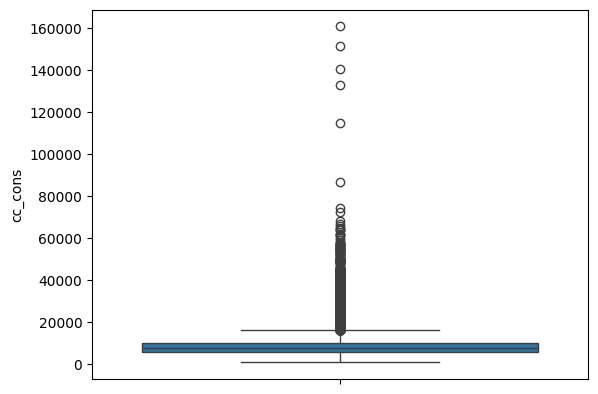

In [29]:
sns.boxplot(df['cc_cons'])
plt.show()

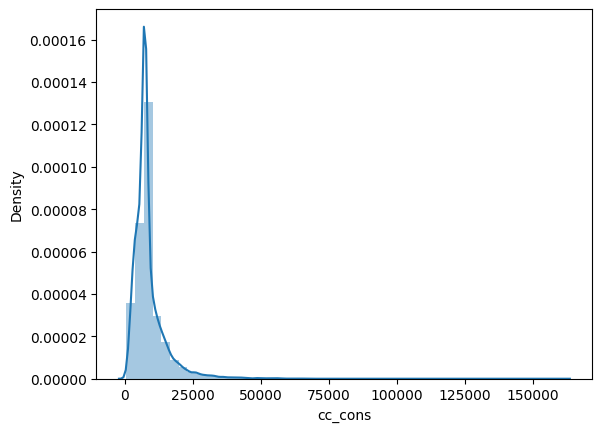

In [30]:
sns.distplot(df['cc_cons'])
plt.show()

applying outlier_capping

In [31]:
def outlier_capping(x):
    x = x.clip(upper = x.quantile(0.99)+0.5*x.std(), lower = x.quantile(0.01)-0.5*x.std())
    return x

In [32]:
df = df.apply(outlier_capping)

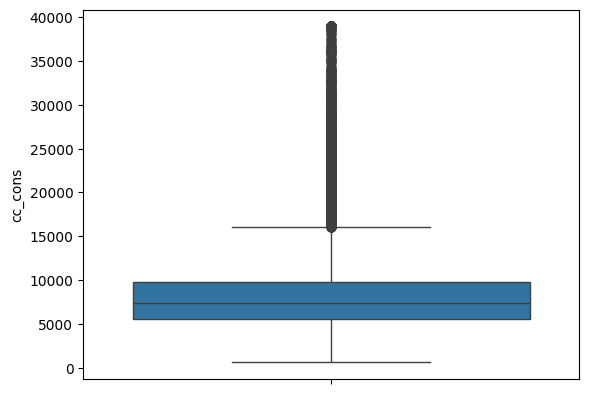

In [33]:
sns.boxplot(df['cc_cons'])
plt.show()

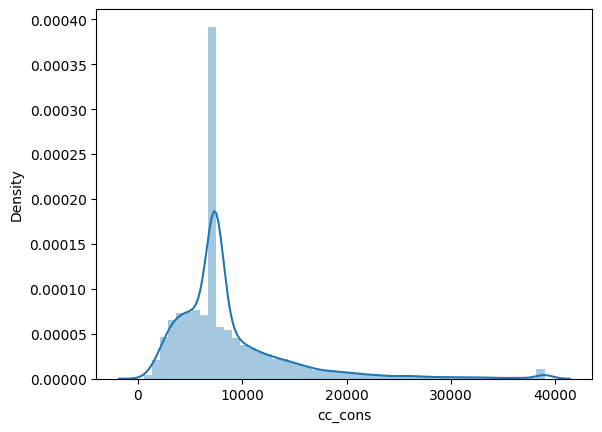

In [34]:
sns.distplot(df['cc_cons'])
plt.show()

In [35]:
df.columns

Index(['ID', 'cc_cons', 'ID', 'cc_cons_apr', 'dc_cons_apr', 'cc_cons_may',
       'dc_cons_may', 'cc_cons_jun', 'dc_cons_jun', 'cc_count_apr',
       'cc_count_may', 'cc_count_jun', 'dc_count_apr', 'dc_count_may',
       'dc_count_jun', 'card_lim', 'personal_loan_active',
       'vehicle_loan_active', 'personal_loan_closed', 'vehicle_loan_closed',
       'investment_1', 'investment_2', 'investment_3', 'investment_4',
       'debit_amount_apr', 'credit_amount_apr', 'debit_count_apr',
       'credit_count_apr', 'max_credit_amount_apr', 'debit_amount_may',
       'credit_amount_may', 'credit_count_may', 'debit_count_may',
       'max_credit_amount_may', 'debit_amount_jun', 'credit_amount_jun',
       'credit_count_jun', 'debit_count_jun', 'max_credit_amount_jun',
       'loan_enq', 'emi_active', 'ID', 'age', 'Emp_Tenure_Years',
       'Tenure_with_Bank', 'region_code', 'NetBanking_Flag',
       'Avg_days_between_transaction', 'account_type_current',
       'account_type_saving', 'gender_F

In [36]:
sel_col = df[['cc_cons_apr', 'dc_cons_apr', 'cc_cons_may',
       'dc_cons_may', 'cc_cons_jun', 'dc_cons_jun', 'cc_count_apr',
       'cc_count_may', 'cc_count_jun', 'dc_count_apr', 'dc_count_may',
       'dc_count_jun', 'card_lim', 'personal_loan_active',
       'vehicle_loan_active', 'personal_loan_closed', 'vehicle_loan_closed',
       'investment_1', 'investment_2', 'investment_3', 'investment_4',
       'debit_amount_apr', 'credit_amount_apr', 'debit_count_apr',
       'credit_count_apr', 'max_credit_amount_apr', 'debit_amount_may',
       'credit_amount_may', 'credit_count_may', 'debit_count_may',
       'max_credit_amount_may', 'debit_amount_jun', 'credit_amount_jun',
       'credit_count_jun', 'debit_count_jun', 'max_credit_amount_jun',
       'loan_enq', 'emi_active', 'age', 'Emp_Tenure_Years', 'NetBanking_Flag',
       'Avg_days_between_transaction', 'account_type_current',
       'account_type_saving', 'gender_F', 'gender_M', 'Income_HIGH',
       'Income_LOW', 'Income_MEDIUM']]

feature_selection


In [37]:
vif = pd.DataFrame()
vif['feature'] = sel_col.columns
vif['vif_predict'] = [variance_inflation_factor(sel_col,i) for i in range(len(sel_col.columns))]

In [38]:
vif_sel = vif.loc[vif['vif_predict']>=2,['feature']]

In [39]:
vif_sel

,feature
42,account_type_current
43,account_type_saving
44,gender_F
45,gender_M
46,Income_HIGH
47,Income_LOW
48,Income_MEDIUM


In [40]:
df_new = df[['cc_cons','account_type_current',
       'account_type_saving',
       'gender_F',
       'gender_M',
       'Income_HIGH',
       'Income_LOW',
       'Income_MEDIUM']]

In [41]:
df_new

,cc_cons,account_type_current,account_type_saving,gender_F,gender_M,Income_HIGH,Income_LOW,Income_MEDIUM
0,16239.000000,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,38951.993371,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,21182.000000,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,8123.000000,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,28282.000000,0.0,1.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...
19995,7408.604400,1.0,0.0,0.0,1.0,0.0,0.0,1.0
19996,7408.604400,1.0,0.0,0.0,1.0,0.0,0.0,1.0
19997,7408.604400,1.0,0.0,0.0,1.0,1.0,0.0,0.0
19998,7408.604400,1.0,0.0,0.0,1.0,0.0,0.0,1.0


spliting the data

In [42]:
train,test = train_test_split(df_new,test_size=0.3,random_state=123)

model_building using traditionl and advance machine_learning model


In [43]:
linear_model = LinearRegression()

In [44]:
sel_linear_col = df_new.columns.difference(['cc_cons'])

In [45]:
sel_linear_col

Index(['Income_HIGH', 'Income_LOW', 'Income_MEDIUM', 'account_type_current',
       'account_type_saving', 'gender_F', 'gender_M'],
      dtype='object')

In [46]:
formula = 'cc_cons~'+'+'.join(sel_linear_col)

In [47]:
formula

'cc_cons~Income_HIGH+Income_LOW+Income_MEDIUM+account_type_current+account_type_saving+gender_F+gender_M'

In [48]:
m0 = smf.ols(formula = formula, data = train).fit()

In [49]:
print(m0.summary())

                            OLS Regression Results                            
Dep. Variable:                cc_cons   R-squared:                      -0.001
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    -2.533
Date:                Mon, 11 May 2026   Prob (F-statistic):               1.00
Time:                        12:08:07   Log-Likelihood:            -1.4113e+05
No. Observations:               14000   AIC:                         2.823e+05
Df Residuals:                   13993   BIC:                         2.823e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept            -9.873e+15 

In [50]:
m0.predict(train)

,0
8659,8696.000000
12631,8583.947687
9579,8583.947687
6252,8506.000000
11927,8449.075200
...,...
7763,8318.390868
15377,8583.947687
17730,8506.000000
15725,8374.000000


In [51]:
train['predected'] = np.where(m0.predict(train)>=0.5,1,0)
test['predected'] = np.where(m0.predict(test)>=0.5,1,0)

In [52]:
train['predected'].value_counts()

,count
predected,
1,14000


In [53]:
test['predected'].value_counts()

,count
predected,
1,5999
0,1


In [54]:
df_new.columns

Index(['cc_cons', 'account_type_current', 'account_type_saving', 'gender_F',
       'gender_M', 'Income_HIGH', 'Income_LOW', 'Income_MEDIUM'],
      dtype='object')

In [55]:
x = df_new[['account_type_current', 'account_type_saving', 'gender_F',
       'gender_M', 'Income_HIGH', 'Income_LOW', 'Income_MEDIUM']]
y = df_new['cc_cons']

In [56]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=123)

In [57]:
std = StandardScaler()

In [58]:
x_train_std = std.fit_transform(x_train)
x_test_std = std.transform(x_test)

In [59]:
KNeighborsRegressor?

In [60]:
para_knn = {'n_neighbors':[1,2,3,4,5,6,7,8,9,10],'weights':['uniform', 'distance']}

In [61]:
grid_cv_knn = GridSearchCV(KNeighborsRegressor(), param_grid=para_knn, cv=5, n_jobs=1)

In [62]:
grid_cv_knn = grid_cv_knn.fit(x_train_std,y_train)

In [63]:
grid_cv_knn.best_params_

{'n_neighbors': 8, 'weights': 'uniform'}

In [64]:
grid_cv_knn.best_score_

np.float64(-0.08586784413585428)

In [65]:
knn_model = grid_cv_knn.best_estimator_

In [66]:
knn_model = knn_model.fit(x_train,y_train)

In [67]:
root_mean_squared_error(y_train,knn_model.predict(x_train))

5963.9676787694925

In [68]:
root_mean_squared_error(y_test,knn_model.predict(x_test))

6171.160502249254

In [69]:
DecisionTreeRegressor?

In [70]:
para_decision = {'max_depth':[1,2,3,4,5,6,7,8,9,10],
                 'min_samples_split':[2,3,4,5,6,7,8,9,10],
                 'min_samples_leaf':[1,2,3,4,5,6,7,8,9,10],
                 'max_features':[1,2,3,4,5,6,7]}

In [71]:
grid_cv_tree = GridSearchCV(DecisionTreeRegressor(), param_grid=para_decision, cv=5, n_jobs=1)

In [73]:
grid_cv_tree = grid_cv_tree.fit(x_train,y_train)

In [74]:
grid_cv_tree.best_params_

{'max_depth': 1,
 'max_features': 3,
 'min_samples_leaf': 6,
 'min_samples_split': 8}

In [75]:
grid_cv_tree.best_score_

np.float64(-0.00024136858552512575)

In [76]:
tree_model = grid_cv_tree.best_estimator_

In [77]:
tree_model = tree_model.fit(x_train,y_train)

In [78]:
root_mean_squared_error(y_train,tree_model.predict(x_train))

5772.569818055181

In [79]:
root_mean_squared_error(y_test,tree_model.predict(x_test))

5977.747388214261

In [80]:
BaggingRegressor?

In [81]:
para_bag = {'n_estimators':[1,2,3,4,5,6,7,8,9],
            'max_samples':[1,2,3,4,5,6,7,8,9],
            'max_features':[1,2,3,4,5,6,7,8,9]}

In [82]:
grid_cv_bag = GridSearchCV(BaggingRegressor(), param_grid=para_bag, cv=5, n_jobs=1)

In [83]:
grid_cv_bag = grid_cv_bag.fit(x_train,y_train)

In [84]:
grid_cv_bag.best_params_

{'max_features': 1, 'max_samples': 8, 'n_estimators': 8}

In [85]:
grid_cv_bag.best_score_

np.float64(-0.00915243333789566)

In [86]:
bag_model = grid_cv_bag.best_estimator_

In [87]:
bag_model = bag_model.fit(x_train,y_train)

In [88]:
root_mean_squared_error(y_train,bag_model.predict(x_train))

6064.276098588633

In [89]:
root_mean_squared_error(y_test,bag_model.predict(x_test))

6226.744531404348

In [90]:
RandomForestRegressor?

In [ ]:
para_forest = {'n_estimators':[1,2,3,4,5,6,7,8,9,10],
               'max_depth':[1,2,3,4,5,6,7,8,9,10],
               'min_samples_split':[1,2,3,4,5,6,7,8,9,10],
               'min_samples_leaf':[1,2,3,4,5,6,7,8,9,10],
               'max_features':[1,2,3,4,5,6,7,8,9,10],
               'oob_score':[True]}

In [95]:
grid_cv_forest = GridSearchCV(RandomForestRegressor(), param_grid=para_forest, cv=5, n_jobs=1)

In [96]:
grid_cv_forest = grid_cv_forest.fit(x_train,y_train)

In [97]:
grid_cv_forest.best_params_

{'max_depth': 1,
 'max_features': 3,
 'min_samples_leaf': 5,
 'min_samples_split': 5,
 'n_estimators': 1,
 'oob_score': True}

In [98]:
grid_cv_forest.best_score_

np.float64(-0.0019054791855677156)

In [99]:
forest_model = grid_cv_forest.best_estimator_

In [100]:
forest_model = forest_model.fit(x_train,y_train)

In [101]:
root_mean_squared_error(y_train,forest_model.predict(x_train))

5773.073048225473

In [102]:
root_mean_squared_error(y_test,forest_model.predict(x_test))

5976.793198912967

In [103]:
AdaBoostRegressor?

In [104]:
para_ada = {'n_estimators' : [10,20,30,40,50,60,70,80,90,100],
            'learning_rate' : [0.01,0.05,0.1,0.5,1]}

In [105]:
grid_cv_ada = GridSearchCV(AdaBoostRegressor(), param_grid=para_ada, cv=5, n_jobs=1)

In [106]:
grid_cv_ada = grid_cv_ada.fit(x_train,y_train)

In [107]:
grid_cv_ada.best_params_

{'learning_rate': 0.01, 'n_estimators': 10}

In [108]:
grid_cv_ada.best_score_

np.float64(-0.0015818068560768729)

In [109]:
ada_model = grid_cv_ada.best_estimator_

In [110]:
ada_model = ada_model.fit(x_train,y_train)

In [119]:
root_mean_squared_error(y_train,ada_model.predict(x_train))

5772.567920191691

In [112]:
root_mean_squared_error(y_test,ada_model.predict(x_test))

5976.37139891835

In [113]:
GradientBoostingRegressor?

In [121]:
para_grid = {'learning_rate' : [0.05,0.5,1],
             'n_estimators' : [10,50,100],
             'min_samples_split':[2,3,4,5],
             'min_samples_leaf':[2,3,4,5],
             'max_depth':[2,3,4,5],'max_features':[2,3,4,5]
             }

In [122]:
grid_cv_grad = GridSearchCV(GradientBoostingRegressor(), param_grid=para_grid, cv=5, n_jobs=1)

In [123]:
grid_cv_grad = grid_cv_grad.fit(x_train,y_train)

In [124]:
grid_cv_grad.best_params_

{'learning_rate': 0.05,
 'max_depth': 2,
 'max_features': 2,
 'min_samples_leaf': 3,
 'min_samples_split': 5,
 'n_estimators': 10}

In [125]:
grid_cv_grad.best_score_

np.float64(-0.0005710137596746767)

In [126]:
model_grad = grid_cv_grad.best_estimator_

In [127]:
model_grad = model_grad.fit(x_train,y_train)

In [128]:
root_mean_squared_error(y_train,model_grad.predict(x_train))

5772.618479958202

In [129]:
root_mean_squared_error(y_test,model_grad.predict(x_test))

5977.768443667693

In [130]:
XGBRegressor?

In [131]:
para_xgb = {'n_estimators' : [10,40,50,100],'max_dept':[4,5,6,7,8,9],
             'max_leaves' : [4,5,6,7,8,9],'learning_rate':[0.01,0.05,0.5,1]}

In [132]:
grid_cv_xgb = GridSearchCV(XGBRegressor(), param_grid=para_xgb, cv=5, n_jobs=1)

In [133]:
grid_cv_xgb = grid_cv_xgb.fit(x_train,y_train)

In [134]:
grid_cv_xgb.best_params_

{'learning_rate': 0.01, 'max_dept': 4, 'max_leaves': 4, 'n_estimators': 10}

In [135]:
grid_cv_xgb.best_score_

np.float64(-0.0004966917762421197)

In [136]:
model_grad = grid_cv_xgb.best_estimator_

In [137]:
model_grad = model_grad.fit(x_train,y_train)

In [138]:
root_mean_squared_error(y_train,model_grad.predict(x_train))

5772.973424230891

In [139]:
root_mean_squared_error(y_test,model_grad.predict(x_test))

5977.971029030211

In [145]:
CatBoostRegressor?

In [146]:
para_cat = {'loss_function' : ['RMSE', 'MAE','Poisson','MAPE']}

In [147]:
grid_cv_cat = GridSearchCV(CatBoostRegressor(), param_grid=para_cat, cv=5, n_jobs=1)

In [148]:
grid_cv_cat = grid_cv_cat.fit(x_train,y_train)

Streaming output truncated to the last 5000 lines.
1:	learn: 0.4267504	total: 3.64ms	remaining: 1.82s
2:	learn: 0.4267387	total: 5.66ms	remaining: 1.88s
3:	learn: 0.4267271	total: 7.58ms	remaining: 1.89s
4:	learn: 0.4267270	total: 8.97ms	remaining: 1.78s
5:	learn: 0.4267158	total: 10.8ms	remaining: 1.79s
6:	learn: 0.4267051	total: 12.7ms	remaining: 1.8s
7:	learn: 0.4266949	total: 14.6ms	remaining: 1.8s
8:	learn: 0.4266883	total: 16.4ms	remaining: 1.81s
9:	learn: 0.4266883	total: 17.9ms	remaining: 1.77s
10:	learn: 0.4266861	total: 19.5ms	remaining: 1.76s
11:	learn: 0.4266860	total: 20.9ms	remaining: 1.72s
12:	learn: 0.4266858	total: 22.4ms	remaining: 1.7s
13:	learn: 0.4266858	total: 23.9ms	remaining: 1.68s
14:	learn: 0.4266827	total: 25.7ms	remaining: 1.69s
15:	learn: 0.4266808	total: 27.6ms	remaining: 1.7s
16:	learn: 0.4266806	total: 29.1ms	remaining: 1.68s
17:	learn: 0.4266801	total: 30.7ms	remaining: 1.67s
18:	learn: 0.4266782	total: 32.5ms	remaining: 1.68s
19:	learn: 0.4266764	total

In [149]:
grid_cv_cat.best_params_

{'loss_function': 'RMSE'}

In [150]:
grid_cv_cat.best_score_

np.float64(-0.0016541833468240342)

In [151]:
model_cat = grid_cv_cat.best_estimator_

In [152]:
model_cat = model_cat.fit(x_train,y_train)

Learning rate set to 0.062125
0:	learn: 5772.8867586	total: 4.37ms	remaining: 4.36s
1:	learn: 5772.7708208	total: 7.51ms	remaining: 3.75s
2:	learn: 5772.6053540	total: 10.8ms	remaining: 3.57s
3:	learn: 5772.5400892	total: 13.3ms	remaining: 3.31s
4:	learn: 5772.4018874	total: 16.1ms	remaining: 3.2s
5:	learn: 5772.2798781	total: 19ms	remaining: 3.14s
6:	learn: 5772.1723340	total: 21.6ms	remaining: 3.06s
7:	learn: 5772.0776222	total: 28.5ms	remaining: 3.53s
8:	learn: 5772.0240465	total: 32.3ms	remaining: 3.56s
9:	learn: 5771.9906508	total: 34.8ms	remaining: 3.44s
10:	learn: 5771.9330330	total: 37.3ms	remaining: 3.36s
11:	learn: 5771.8662766	total: 40ms	remaining: 3.29s
12:	learn: 5771.8551689	total: 42ms	remaining: 3.19s
13:	learn: 5771.8259998	total: 44.2ms	remaining: 3.11s
14:	learn: 5771.7719127	total: 46.9ms	remaining: 3.08s
15:	learn: 5771.7359708	total: 49.3ms	remaining: 3.03s
16:	learn: 5771.7324708	total: 51.2ms	remaining: 2.96s
17:	learn: 5771.7124430	total: 53.5ms	remaining: 2.9

In [153]:
root_mean_squared_error(y_train,model_cat.predict(x_train))

5771.342912681376

In [154]:
root_mean_squared_error(y_test,model_cat.predict(x_test))

5977.23525043765

In [174]:
LGBMRegressor?

In [175]:
para_lgbm = {'max_depth':[5,6,7,8,9],'learning_rate':[0.01,0.05,0.5,1],
             'n_estimators':[10,50,100],'subsample':[1,2,3,4,5]}

In [176]:
grid_cv_lgbm = GridSearchCV(LGBMRegressor(), param_grid=para_lgbm, cv=5, n_jobs=1)

In [177]:
grid_cv_lgbm = grid_cv_lgbm.fit(x_train,y_train)

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

In [178]:
grid_cv_lgbm.best_params_

{'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 10, 'subsample': 1}

In [179]:
grid_cv_lgbm.best_score_

np.float64(-0.0005196128095553476)

In [180]:
model_lgbm = grid_cv_lgbm.best_estimator_

In [181]:
model_lgbm = model_lgbm.fit(x_train,y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001291 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14
[LightGBM] [Info] Number of data points in the train set: 14000, number of used features: 7
[LightGBM] [Info] Start training from score 8751.591040
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [182]:
root_mean_squared_error(y_train,model_lgbm.predict(x_train))

5772.77559559823

In [183]:
root_mean_squared_error(y_test,model_lgbm.predict(x_test))

5977.77895884733

In [158]:
SVC?

In [163]:
para_svc = {'C':[0.001,0.01,0.1,1,10],'kernel' : ['linear', 'poly', 'rbf', 'sigmoid']}

In [164]:
grid_cv_svc = GridSearchCV(SVR(), param_grid=para_svc, cv=5, n_jobs=1)

In [165]:
grid_cv_svc = grid_cv_svc.fit(x_train_std,y_train)

In [166]:
grid_cv_svc.best_params_


{'C': 0.1, 'kernel': 'poly'}

In [167]:
grid_cv_svc.best_score_

np.float64(-0.05421402934602089)

In [168]:
model_svc = grid_cv_svc.best_estimator_

In [169]:
model_svc = model_svc.fit(x_train_std,y_train)

In [170]:
root_mean_squared_error(y_train,model_svc.predict(x_train_std))

5927.230532552971

In [171]:
root_mean_squared_error(y_test,model_svc.predict(x_test_std))

6151.182774347282

In [172]:
estimators = []

In [184]:
estimators.append(('knn',grid_cv_knn.best_estimator_))
estimators.append(('tree',grid_cv_tree.best_estimator_))
estimators.append(('bag',grid_cv_bag.best_estimator_))
estimators.append(('forest',grid_cv_forest.best_estimator_))
estimators.append(('ada',grid_cv_ada.best_estimator_))
estimators.append(('grad',grid_cv_grad.best_estimator_))
estimators.append(('xgb',grid_cv_xgb.best_estimator_))
estimators.append(('cat',grid_cv_cat.best_estimator_))
estimators.append(('svc',grid_cv_svc.best_estimator_))
estimators.append(('light',grid_cv_lgbm.best_estimator_))

In [185]:
estimators

[('knn', KNeighborsRegressor(n_neighbors=8)),
 ('tree',
  DecisionTreeRegressor(max_depth=1, max_features=3, min_samples_leaf=6,
                        min_samples_split=8)),
 ('bag', BaggingRegressor(max_features=1, max_samples=8, n_estimators=8)),
 ('forest',
  RandomForestRegressor(max_depth=1, max_features=3, min_samples_leaf=5,
                        min_samples_split=5, n_estimators=1, oob_score=True)),
 ('ada', AdaBoostRegressor(learning_rate=0.01, n_estimators=10)),
 ('grad',
  GradientBoostingRegressor(learning_rate=0.05, max_depth=2, max_features=2,
                            min_samples_leaf=3, min_samples_split=5,
                            n_estimators=10)),
 ('xgb',
  XGBRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_we

In [193]:
VotingRegressor?

In [201]:
para_vote = {'estimators':[estimators]}

In [202]:
grid_cv_vote = GridSearchCV(VotingRegressor(estimators=estimators), param_grid=para_vote, cv=5, n_jobs=1)

In [203]:
grid_cv_vote = grid_cv_vote.fit(x_train,y_train)

Streaming output truncated to the last 5000 lines.
83:	learn: 5819.7949774	total: 324ms	remaining: 3.54s
84:	learn: 5819.7949648	total: 327ms	remaining: 3.52s
85:	learn: 5819.7944986	total: 333ms	remaining: 3.54s
86:	learn: 5819.7917096	total: 339ms	remaining: 3.56s
87:	learn: 5819.7917091	total: 343ms	remaining: 3.55s
88:	learn: 5819.7916709	total: 346ms	remaining: 3.55s
89:	learn: 5819.7916620	total: 350ms	remaining: 3.54s
90:	learn: 5819.7891820	total: 355ms	remaining: 3.54s
91:	learn: 5819.7891046	total: 358ms	remaining: 3.54s
92:	learn: 5819.7889950	total: 362ms	remaining: 3.53s
93:	learn: 5819.7889879	total: 366ms	remaining: 3.53s
94:	learn: 5819.7888966	total: 370ms	remaining: 3.53s
95:	learn: 5819.7888716	total: 374ms	remaining: 3.52s
96:	learn: 5819.7884220	total: 379ms	remaining: 3.53s
97:	learn: 5819.7881433	total: 390ms	remaining: 3.59s
98:	learn: 5819.7881225	total: 396ms	remaining: 3.6s
99:	learn: 5819.7880476	total: 402ms	remaining: 3.62s
100:	learn: 5819.7859684	total: 

In [204]:
grid_cv_vote.best_params_

{'estimators': [('knn', KNeighborsRegressor(n_neighbors=8)),
  ('tree',
   DecisionTreeRegressor(max_depth=1, max_features=3, min_samples_leaf=6,
                         min_samples_split=8)),
  ('bag', BaggingRegressor(max_features=1, max_samples=8, n_estimators=8)),
  ('forest',
   RandomForestRegressor(max_depth=1, max_features=3, min_samples_leaf=5,
                         min_samples_split=5, n_estimators=1, oob_score=True)),
  ('ada', AdaBoostRegressor(learning_rate=0.01, n_estimators=10)),
  ('grad',
   GradientBoostingRegressor(learning_rate=0.05, max_depth=2, max_features=2,
                             min_samples_leaf=3, min_samples_split=5,
                             n_estimators=10)),
  ('xgb',
   XGBRegressor(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=False, eval_metric=None, feature_types

In [205]:
grid_cv_vote.best_score_

np.float64(-0.0021852269236000586)

In [206]:
voting =grid_cv_vote.best_estimator_

In [207]:
voting = voting.fit(x_train,y_train)

Learning rate set to 0.062125
0:	learn: 5772.8867586	total: 4.02ms	remaining: 4.01s
1:	learn: 5772.7708208	total: 6.57ms	remaining: 3.28s
2:	learn: 5772.6053540	total: 9.65ms	remaining: 3.21s
3:	learn: 5772.5400892	total: 12.2ms	remaining: 3.04s
4:	learn: 5772.4018874	total: 15.2ms	remaining: 3.02s
5:	learn: 5772.2798781	total: 18.1ms	remaining: 2.99s
6:	learn: 5772.1723340	total: 21ms	remaining: 2.98s
7:	learn: 5772.0776222	total: 23.8ms	remaining: 2.95s
8:	learn: 5772.0240465	total: 26.8ms	remaining: 2.95s
9:	learn: 5771.9906508	total: 29.4ms	remaining: 2.91s
10:	learn: 5771.9330330	total: 37.3ms	remaining: 3.35s
11:	learn: 5771.8662766	total: 42.9ms	remaining: 3.53s
12:	learn: 5771.8551689	total: 45ms	remaining: 3.42s
13:	learn: 5771.8259998	total: 47.3ms	remaining: 3.33s
14:	learn: 5771.7719127	total: 50.3ms	remaining: 3.3s
15:	learn: 5771.7359708	total: 53.6ms	remaining: 3.3s
16:	learn: 5771.7324708	total: 55.9ms	remaining: 3.23s
17:	learn: 5771.7124430	total: 58.3ms	remaining: 3.

In [208]:
root_mean_squared_error(y_train,voting.predict(x_train))

5775.6687642733805

In [209]:
root_mean_squared_error(y_test,voting.predict(x_test))

5982.426398941477

In [213]:
name = pd.DataFrame(['knn','tree','bag','forest','ada','grad','xgb','cat','svc','light','voting'])

In [214]:
score = pd.DataFrame([grid_cv_knn.best_score_,grid_cv_tree.best_score_,grid_cv_bag.best_score_,
                      grid_cv_forest.best_score_,grid_cv_ada.best_score_,grid_cv_grad.best_score_,
                      grid_cv_xgb.best_score_,grid_cv_cat.best_score_,grid_cv_svc.best_score_,
                      grid_cv_lgbm.best_score_,grid_cv_vote.best_score_])

In [215]:
best_scores = pd.concat([name,score],axis=1)

In [217]:
best_scores.columns = ['model','best_score']

In [218]:
best_scores

,model,best_score
0,knn,-0.085868
1,tree,-0.000241
2,bag,-0.009152
3,forest,-0.001905
4,ada,-0.001582
5,grad,-0.000571
6,xgb,-0.000497
7,cat,-0.001654
8,svc,-0.054214
9,light,-0.000520


In [219]:
best_scores.sort_values(by='best_score', ascending=False).head(1)

,model,best_score
1,tree,-0.000241


choosing the best_model score and loading it to the pkl file

In [220]:
import joblib

In [221]:
joblib.dump(grid_cv_tree,'tree.pkl')

['tree.pkl']

In [222]:
joblib.load('tree.pkl')

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(), n_jobs=1,
             param_grid={'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'max_features': [1, 2, 3, 4, 5, 6, 7],
                         'min_samples_leaf': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'min_samples_split': [2, 3, 4, 5, 6, 7, 8, 9, 10]})

In [ ]:
#End